<a href="https://colab.research.google.com/github/sayandeepr8/Lab1/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx matplotlib

Problem 3: Checking Routes Between Cities Using DFS
Problem Statement:
A small road network connects several cities. Write a Python program using DFS that:
1. Checks whether a route exists between two given cities.
2. Finds all separate groups of cities that are connected to each other but not to any
other group (these are called connected components).

Enter number of cities: 8
Enter city 1: Pune
Enter city 2: Mumbai
Enter city 3: Bankura
Enter city 4: Durgapur
Enter city 5: Kolkata
Enter city 6: Asansol
Enter city 7: Dhanbad
Enter city 8: Ranchi

Enter number of roads: 6
Enter road 1 (City1 City2): Pune Mumbai
Enter road 2 (City1 City2): Bankura Durgapur
Enter road 3 (City1 City2): Durgapur Kolkata
Enter road 4 (City1 City2): Kolkata Asansol
Enter road 5 (City1 City2): Asansol Dhanbad
Enter road 6 (City1 City2): Dhanbad Ranchi

Enter starting city: Bankura
Enter destination city: Ranchi

Route exists from Bankura to Ranchi

Connected Components:
Component 1 : Pune -> Mumbai
Component 2 : Bankura -> Durgapur -> Kolkata -> Asansol -> Dhanbad -> Ranchi


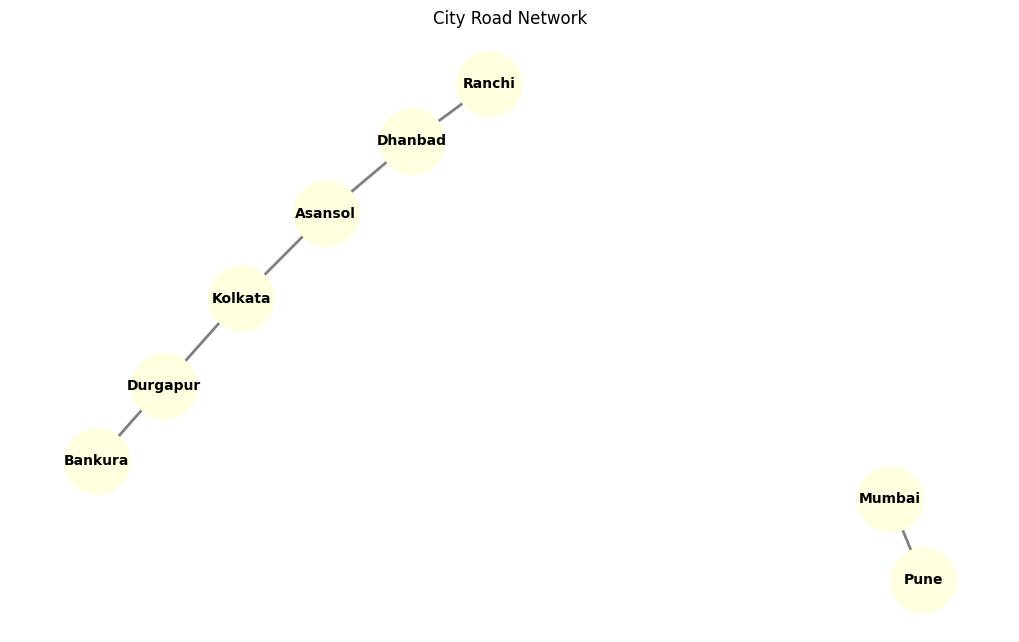

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. INPUT CITIES
# ==========================================

n = int(input("Enter number of cities: "))

graph = {}

for i in range(n):
    city = input(f"Enter city {i + 1}: ").strip()
    graph[city] = []

# ==========================================
# 2. INPUT ROADS
# ==========================================

r = int(input("\nEnter number of roads: "))

for i in range(r):
    a, b = input(
        f"Enter road {i + 1} (City1 City2): "
    ).split()

    # Check whether cities exist
    if a not in graph or b not in graph:
        print("Error: City not found!")
        continue

    # Two-way road
    graph[a].append(b)
    graph[b].append(a)


# ==========================================
# 3. DFS FOR ROUTE
# ==========================================

def route_exists(city, destination, visited):

    if city == destination:
        return True

    visited.add(city)

    for neighbour in graph[city]:

        if neighbour not in visited:

            if route_exists(neighbour, destination, visited):
                return True

    return False


# ==========================================
# 4. DFS FOR CONNECTED COMPONENTS
# ==========================================

def dfs(city, visited, component):

    visited.add(city)
    component.append(city)

    for neighbour in graph[city]:

        if neighbour not in visited:
            dfs(neighbour, visited, component)


# ==========================================
# 5. CHECK ROUTE
# ==========================================

start = input("\nEnter starting city: ").strip()
destination = input("Enter destination city: ").strip()

if start not in graph or destination not in graph:
    print("Invalid city name!")

elif route_exists(start, destination, set()):
    print("\nRoute exists from", start, "to", destination)

else:
    print("\nNo route exists from", start, "to", destination)


# ==========================================
# 6. FIND CONNECTED COMPONENTS
# ==========================================

visited = set()
components = []

for city in graph:

    if city not in visited:

        component = []

        dfs(city, visited, component)

        components.append(component)


print("\nConnected Components:")

for i, component in enumerate(components, 1):
    print("Component", i, ":", " -> ".join(component))


# ==========================================
# 7. CREATE GRAPH FOR VISUALIZATION
# ==========================================

G = nx.Graph()

for city in graph:
    G.add_node(city)

for city in graph:

    for neighbour in graph[city]:
        G.add_edge(city, neighbour)


# ==========================================
# 8. DRAW GRAPH
# ==========================================

pos = nx.spring_layout(G, seed=10)

plt.figure(figsize=(10, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2200,
    node_color="lightyellow",
    edge_color="gray",
    font_size=10,
    font_weight="bold",
    width=2
)

plt.title("City Road Network")
plt.axis("off")
plt.show()